# 3. Graph-EVT: многоканальная POT-детекция

**Цель:** применить `GraphEVTPipeline` к Kuramoto-ряду с впрыснутым событием, оценить POT/GPD-порог на baseline и проверить устойчивое превышение агрегированного индикатора. Baseline здесь заканчивается точно перед известным onset (`event_onset` из `synthetic_datasets_metadata.json`) — как и в `1-d/03`, это oracle-assisted выбор, допустимый только потому, что этот ряд синтетический и размеченный; для неразмеченных реальных данных он неприменим (диагностика без оракула — ноутбук 8).

In [1]:
from pathlib import Path
from importlib.metadata import version
import json
import numpy as np
import pandas as pd
from graph_evt_agent import EVTConfig, GraphConfig, GraphEVTPipeline, InputConfig

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data/generated/kuramoto_propagation_series.csv").exists())
DATA = ROOT / "data/generated/kuramoto_propagation_series.csv"
SEED = 42
df = pd.read_csv(DATA)
channel_names = [column for column in df.columns if column.startswith("channel_")]
x = df[channel_names].to_numpy()
event_mask = df["is_extreme"].to_numpy(dtype=bool)
assert np.isfinite(x).all() and x.ndim == 2
assert event_mask.any(), "Generated dataset must contain a labeled event"

# The CSV's is_extreme marks *when*; the source channel is only in the
# generator's own metadata (it is not, and should not be, a CSV column).
propagation_metadata = json.loads((ROOT / "data/generated/synthetic_datasets_metadata.json").read_text())["kuramoto_propagation"]
event_onset = int(np.flatnonzero(event_mask)[0])
event_end = int(np.flatnonzero(event_mask)[-1])
true_source_channel = int(propagation_metadata["source_channel"])
true_source_name = channel_names[true_source_channel]

In [2]:
BASELINE_SIZE = event_onset
evt_config = EVTConfig(
    baseline_size=BASELINE_SIZE,
    tail_quantile=0.85,
    alarm_probability=0.97,
    top_k=3,
    persistence=1,
)
pipeline = GraphEVTPipeline(
    evt_config,
    graph=GraphConfig(method="ar", edge_threshold=0.35, random_state=SEED),
    input_config=InputConfig(missing="error", require_regular_time=True),
    verbose=True,
)
result = pipeline.run_detailed(x)
detection = result.detection
alarm_index = detection.time_index
detected_in_labeled_event = alarm_index is not None and bool(event_mask[int(alarm_index)])
detection_delay = int(alarm_index) - event_onset if alarm_index is not None else None
estimated_source = None if result.ranking is None else channel_names[result.ranking.source]
source_correct = estimated_source == true_source_name

pd.DataFrame([{
    "observations": result.input_profile.n_time,
    "channels": result.input_profile.n_channels,
    "baseline_size": BASELINE_SIZE,
    "labeled_event_onset": event_onset,
    "labeled_event_end": event_end,
    "alarm_threshold": detection.alarm_threshold,
    "detected": detection.detected,
    "time_index": alarm_index,
    "detected_in_labeled_event": detected_in_labeled_event,
    "detection_delay_samples": detection_delay,
    "graph_available": result.graph is not None,
    "true_source": true_source_name,
    "estimated_source": estimated_source,
    "source_correct": source_correct,
}])

Graph-EVT pipeline:   0%|          | 0/5 [00:00<?, ?it/s]

,observations,channels,baseline_size,labeled_event_onset,labeled_event_end,alarm_threshold,detected,time_index,detected_in_labeled_event,detection_delay_samples,graph_available,true_source,estimated_source,source_correct
0,1500,12,932,932,1036,1.076386,True,949,True,17,True,channel_00,channel_00,True


## Как и где сработал EVT

Две проекции одного и того же результата: **когда** индикатор впервые устойчиво пересёк порог (временная ось) и **на каком канале** сосредоточился отклик после тревоги (пространственная ось / ranking). Правая панель — не отдельный анализ, а разбор того же `result.ranking`, который уже вошёл в таблицу выше.

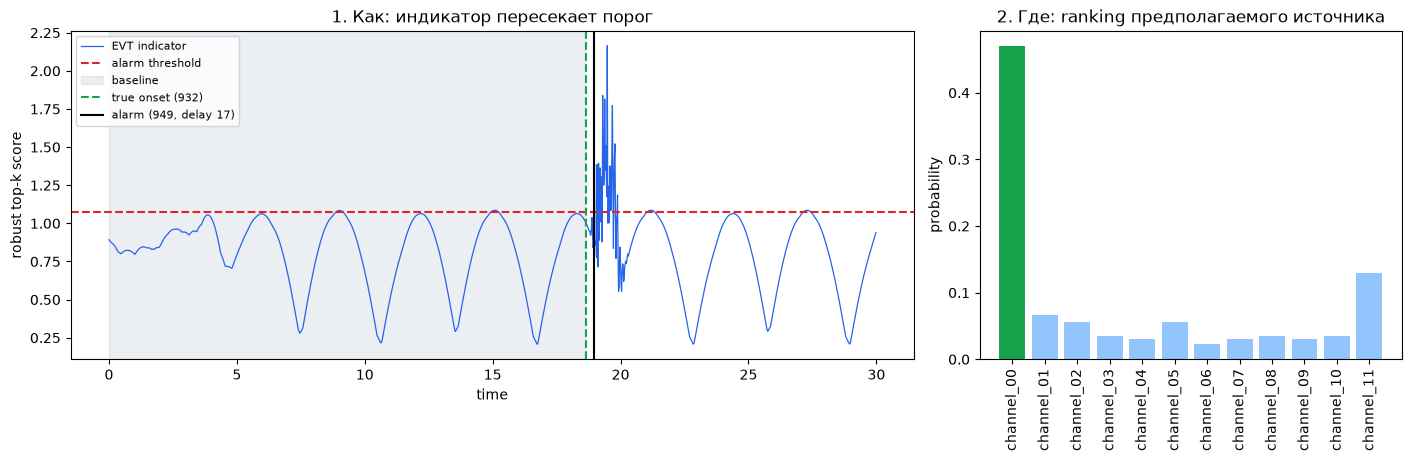

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True, gridspec_kw={"width_ratios": [2, 1]})

# 1. "How": the indicator crossing the frozen POT/GPD threshold over time.
timestamps = df["timestamp"].to_numpy()
axes[0].plot(timestamps, detection.indicator, color="#2563eb", linewidth=0.9, label="EVT indicator")
axes[0].axhline(detection.alarm_threshold, color="#dc2626", linestyle="--", label="alarm threshold")
axes[0].axvspan(timestamps[0], timestamps[BASELINE_SIZE - 1], color="#94a3b8", alpha=0.18, label="baseline")
axes[0].axvline(timestamps[event_onset], color="#16a34a", linewidth=1.5, linestyle="--", label=f"true onset ({event_onset})")
if alarm_index is not None:
    axes[0].axvline(timestamps[alarm_index], color="black", linewidth=1.5, label=f"alarm ({alarm_index}, delay {detection_delay})")
axes[0].set(title="1. Как: индикатор пересекает порог", xlabel="time", ylabel="robust top-k score")
axes[0].legend(loc="upper left", fontsize=8)

# 2. "Where": which channel the post-alarm response ranks as the source.
if result.ranking is not None:
    weights = np.zeros(len(channel_names))
    weights[result.ranking.node_ids] = result.ranking.probabilities
    colors = []
    for name in channel_names:
        if name == true_source_name and name == estimated_source:
            colors.append("#16a34a")   # hit: true and estimated source agree
        elif name == estimated_source:
            colors.append("#dc2626")   # estimated, but not the true source
        elif name == true_source_name:
            colors.append("#a855f7")   # true source, but not top-ranked
        else:
            colors.append("#93c5fd")
    axes[1].bar(channel_names, weights, color=colors)
    axes[1].set(title="2. Где: ranking предполагаемого источника", ylabel="probability")
    axes[1].tick_params(axis="x", rotation=90)
else:
    axes[1].text(0.5, 0.5, "no ranking (no n-D event detected)", ha="center", va="center")
    axes[1].set_axis_off()
plt.show()

Зелёный столбец на правой панели — совпадение: канал с наибольшим весом ranking и есть истинный источник. Если бы столбцы разошлись, они были бы окрашены отдельно (красный — куда указал pipeline, фиолетовый — где событие произошло на самом деле) — именно так выглядит **неверная** локализация в ноутбуке 5 (`persistence=2`).

In [4]:
artifact_dir = ROOT / "results/n-d"
artifact_dir.mkdir(parents=True, exist_ok=True)

indicator_frame = pd.DataFrame({
    "time": df["timestamp"],
    "indicator": detection.indicator,
    "above_alarm_threshold": detection.indicator > detection.alarm_threshold,
    "is_baseline": np.arange(len(x)) < BASELINE_SIZE,
})
indicator_frame.to_csv(artifact_dir / "03_evt_indicator.csv", index=False)

provenance = {
    "library": "graph-evt-agent",
    "library_version": version("graph-evt-agent"),
    "input_file": DATA.name,
    "observations": result.input_profile.n_time,
    "channels": result.input_profile.n_channels,
    "seed": SEED,
    "configuration": {
        "baseline_size": BASELINE_SIZE,
        "baseline_selection": "labeled_event_onset_oracle_assisted",
        "tail_quantile": evt_config.tail_quantile,
        "alarm_probability": evt_config.alarm_probability,
        "persistence": evt_config.persistence,
        "top_k": evt_config.top_k,
        "graph_method": "ar",
    },
    "labeled_event": {"onset": event_onset, "end": event_end, "source_channel": true_source_name},
    "detection": {
        "detected": detection.detected,
        "time_index": detection.time_index,
        "detected_in_labeled_event": detected_in_labeled_event,
        "detection_delay_samples": detection_delay,
        "alarm_threshold": float(detection.alarm_threshold),
    },
    "graph_available": result.graph is not None,
    "ranking_available": result.ranking is not None,
    "estimated_source": estimated_source,
    "source_correct": source_correct,
}
with (artifact_dir / "03_evt_provenance.json").open("w", encoding="utf-8") as file:
    json.dump(provenance, file, indent=2)

provenance

{'library': 'graph-evt-agent',
 'library_version': '0.1.0',
 'input_file': 'kuramoto_propagation_series.csv',
 'observations': 1500,
 'channels': 12,
 'seed': 42,
 'configuration': {'baseline_size': 932,
  'baseline_selection': 'labeled_event_onset_oracle_assisted',
  'tail_quantile': 0.85,
  'alarm_probability': 0.97,
  'persistence': 1,
  'top_k': 3,
  'graph_method': 'ar'},
 'labeled_event': {'onset': 932, 'end': 1036, 'source_channel': 'channel_00'},
 'detection': {'detected': True,
  'time_index': 949,
  'detected_in_labeled_event': True,
  'detection_delay_samples': 17,
  'alarm_threshold': 1.0763861443061515},
 'graph_available': True,
 'ranking_available': True,
 'estimated_source': 'channel_00',
 'source_correct': True}

Оценка использует робастные центр и масштаб чистого участка до начала размеченного события, а граф зависимостей и ranking строятся дополнительно, поскольку событие многоканальное. При текущих настройках (`persistence=1`, `tail_quantile=0.85`) срабатывание попадает внутрь размеченного окна, а оценённый источник совпадает с истинным. Это не гарантия: в ноутбуке 5 та же конфигурация с `persistence=2` находит событие позже и **ошибается** с источником — специфика зависит от формы конкретного импульса, а не является общим свойством библиотеки.

**Самопроверка:** почему при `persistence=2` задержка обнаружения выросла, а источник определился неверно? Что общего между выбором baseline здесь и в `1-d/03`? Почему граф, оценённый по baseline, ничего не говорит о направлении распространения?